In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
from scipy.interpolate import interp1d

In [3]:
data = { "Return period (yr)": [10, 30, 100, 300, 1000, 3000, 10000, 30000, 100000, 300000], 
        "Exceedance probability Pf per yr": [1.0E-01, 3.3E-02, 1.0E-02, 3.3E-03, 1.0E-03,
                                         3.3E-04, 1.0E-04, 3.3E-05, 1.0E-05, 3.3E-06],
        "Water level (m, + NAP)": [3.48, 3.78, 4.07, 4.33, 4.59, 4.83, 5.08, 5.31, 5.56, 5.78]}
waves = pd.DataFrame(data)

In [4]:
F = 1 - waves["Exceedance probability Pf per yr"].values


Estimated Gumbel Parameters:
  Location (mu): 3.0421
  Scale (beta): 0.2199

Moments:
  Mean: 3.1690
  Variance: 0.0795
  Standard Deviation: 0.2820


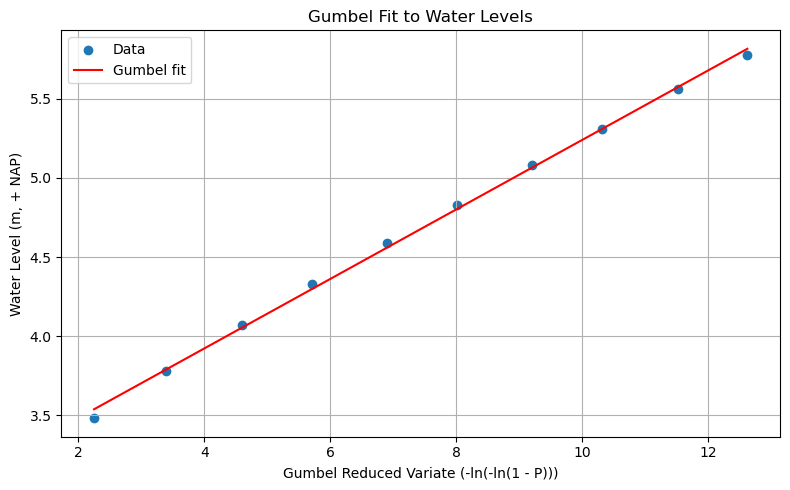

In [5]:
waves['Gumbel variate'] = -np.log(-np.log(1 - waves["Exceedance probability Pf per yr"]))

# Step 2: Linear regression x = mu + beta * y
slope, intercept, r_value, p_value, std_err = stats.linregress(waves['Gumbel variate'], waves['Water level (m, + NAP)'])

beta = slope
mu = intercept

# Step 3: Compute moments
gamma = 0.5772156649  # Euler-Mascheroni constant
mean = mu + gamma * beta
variance = (np.pi**2 / 6) * beta**2
std_dev = np.sqrt(variance)

# Print results
print(f"Estimated Gumbel Parameters:")
print(f"  Location (mu): {mu:.4f}")
print(f"  Scale (beta): {beta:.4f}")
print("\nMoments:")
print(f"  Mean: {mean:.4f}")
print(f"  Variance: {variance:.4f}")
print(f"  Standard Deviation: {std_dev:.4f}")

# Optional: Plot
plt.figure(figsize=(8, 5))
plt.scatter(waves['Gumbel variate'], waves['Water level (m, + NAP)'], label='Data')
plt.plot(waves['Gumbel variate'], mu + beta * waves['Gumbel variate'], color='red', label='Gumbel fit')
plt.xlabel('Gumbel Reduced Variate (-ln(-ln(1 - P)))')
plt.ylabel('Water Level (m, + NAP)')
plt.title('Gumbel Fit to Water Levels')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

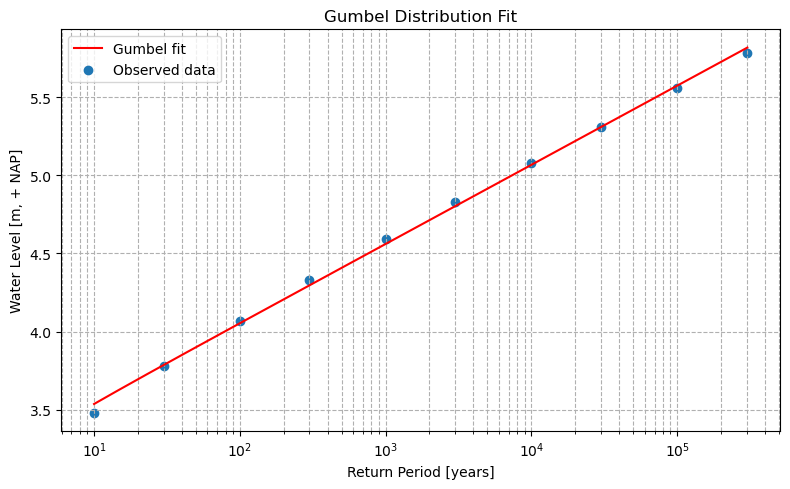

In [6]:
x = np.linspace(waves['Gumbel variate'].min(), waves['Gumbel variate'].max(), 1000)

water_level = mu + beta * x

cdf_gum = stats.gumbel_r.cdf(water_level, loc=mu, scale=beta)
Pf = 1 - cdf_gum
T = 1 / Pf  # Return period in years

# Plot
plt.figure(figsize=(8, 5))
plt.plot(T, water_level, label='Gumbel fit', color='red')
plt.scatter(waves["Return period (yr)"], waves["Water level (m, + NAP)"], label='Observed data')

plt.xscale('log')
plt.xlabel('Return Period [years]')
plt.ylabel('Water Level [m, + NAP]')
plt.title('Gumbel Distribution Fit')
plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig('figures\\gumbel_fit.png', dpi=300)


In [7]:
interp_func = interp1d(T, water_level, kind='linear', bounds_error=False)

# Interpolate water level for return period = 3000 years
return_period_target = 3000
water_level_3000 = interp_func(return_period_target)

print(f"Interpolated water level for a return period of {return_period_target} years: {water_level_3000:.4f} m")

Interpolated water level for a return period of 3000 years: 4.8023 m


In [8]:
print(f"mu: {mu:.4f}, beta: {beta:.4f}, mean: {mean:.4f}, std_dev: {std_dev:.4f}")

mu: 3.0421, beta: 0.2199, mean: 3.1690, std_dev: 0.2820


Upper bound water level for return period of 3000 years: 4.6967 m + NAP
Lower bound water level for return period of 3000 years: 4.8769 m + NAP


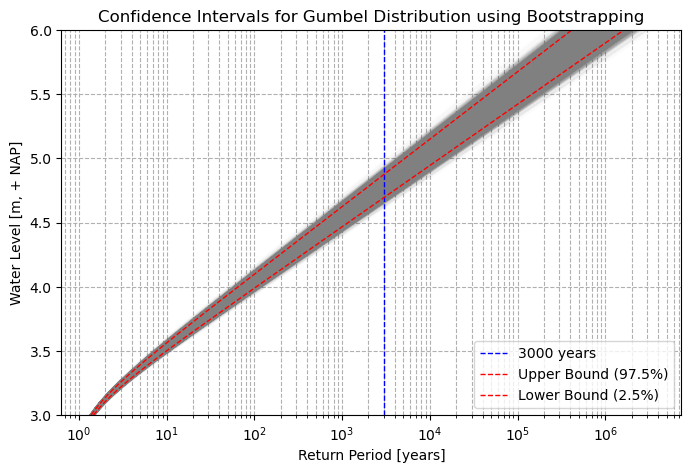

In [ ]:
#parameters
n_btstrap = 1000
n_samples = 1000

#generate data
bootstrap = []
water_lev = np.linspace(3, 6, n_samples)
data = np.random.gumbel(mu, beta, n_samples)

#plottings
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_title('Confidence Intervals for Gumbel Distribution using Bootstrapping')
ax.set_xscale('log')
ax.set_xlabel('Return Period [years]')
ax.set_ylabel('Water Level [m, + NAP]')
ax.set_ylim(water_lev.min(), water_lev.max())


#monte carlo bootstrap
for i in range(n_btstrap):
    #sampling and fitting
    sample_MC = np.random.choice(data, size=n_samples, replace=True)
    # sample_MC = np.random.gumbel(mu, beta, n_samples, replace=True)
    params_MC = stats.gumbel_r.fit(sample_MC)

    #cumulative distribution function
    cdf_MC = stats.gumbel_r.cdf(water_lev, *params_MC)
    rtp_MC = 1 / (1 - cdf_MC)
    bootstrap.append(rtp_MC)
    ax.plot(rtp_MC, water_lev, color='grey', alpha=0.01)

#calculating confidence intervals
upper_bound = np.percentile(bootstrap, 97.5, axis=0)
lower_bound = np.percentile(bootstrap, 2.5, axis=0)

#plottings
ax.axvline(x=3000, color='blue', linestyle='--', label='3000 years', linewidth=1)
ax.grid(True, which='both', linestyle='--')
ax.plot(upper_bound, water_lev, "r--", label='Upper Bound (97.5%)', linewidth=1)
ax.plot(lower_bound, water_lev, "r--", label='Lower Bound (2.5%)', linewidth=1)
ax.legend(loc = 'lower right')

#results
level_up = water_lev[np.where(upper_bound >= 3000)[0]]
level_lo = water_lev[np.where(lower_bound >= 3000)[0]]

print(f"Upper bound water level for return period of 3000 years: {level_up[0]:.4f} m + NAP")
print(f"Lower bound water level for return period of 3000 years: {level_lo[0]:.4f} m + NAP")

plt.savefig('figures\\gumbel_bootstrap.png', dpi=300)

In [ ]:
# # Convert exceedance probabilities to Gumbel variates
# waves['Gumbel variate'] = -np.log(-np.log(1 - (1 - waves['Exceedance probability Pf per yr'])))

# # Fit a linear regression (Gumbel: linear in reduced variate)
# slope, intercept, r_value, p_value, std_err = stats.linregress(waves['Gumbel variate'], waves['Water level (m, + NAP)'])
# mu = intercept
# beta = slope

# # Confidence intervals
# n = len(waves)
# x = np.linspace(waves['Gumbel variate'].min(), waves['Gumbel variate'].max(), 1000)
# y = mu + beta * x

# # Standard error of prediction (delta method)
# y_fit = mu + beta * x
# s_x = np.std(waves['Gumbel variate'], ddof=1)
# SE = std_err * np.sqrt(1/n + ((x - np.mean(waves['Gumbel variate']))**2 / (n * s_x**2)))

# # 95% CI
# CI_upper = y_fit + 1.96 * SE
# CI_lower = y_fit - 1.96 * SE

# # Convert to return period
# Pf = 1 - stats.gumbel_r.cdf(y_fit, loc=mu, scale=beta)
# T = 1 / Pf

# # Plot
# plt.figure(figsize=(8, 5))
# plt.plot(T, y_fit, label='Gumbel fit', color='red')
# plt.fill_between(T, CI_lower, CI_upper, color='red', alpha=0.3, label='95% CI')
# plt.scatter(waves["Return period (yr)"], waves["Water level (m, + NAP)"], label='Observed data')

# plt.xscale('log')
# plt.xlabel('Return Period [years]')
# plt.ylabel('Water Level [m, + NAP]')
# plt.title('Gumbel Distribution Fit with 95% Confidence Interval')
# plt.grid(True, which='both', linestyle='--')
# plt.legend()
# plt.tight_layout()
# plt.savefig('gumbel_fit_with_ci.png', dpi=300)
# plt.show()